In [1]:
import pandas as pd
import numpy as np
import os
import mo_gymnasium as mo_gym
import gymnasium as gym
import sys
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import pymc as pm
import pyperclip

sys.path.append(os.path.abspath('..'))
from env.user_sim import UserSimEnv
import env.simulate as sim_utils
import utils
import process_data as dp
import mdp_utils
import pickle
import bayesian_analysis as ba


%load_ext autoreload
%autoreload 2

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
Failed to read module file 'C:\Python311\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\importlib\_

In [2]:
data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\'

# Load data
action_data = pd.read_csv(os.path.join(data_folder, 'challenge_info.csv'))

In [24]:
evaluation_cols = ["time_spent", "likedness", "usefulness", "difficulty", "PAY_next", "expert_score", "diversity"]
evaluation_names = ["Time Spent", "Perceived Enjoyment", "Perceived Usefulness", "Difficulty", "Return Willingness", "Difficulty-weighted Adherence", "Diversity"]

results_folder = "C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\"
simulation_file = "\\pimorld_P=128_T=5_nO=5_gamma=0.7\\simulations\\combined_simulation_results.pkl"
simulation_results = pd.read_pickle(results_folder + simulation_file)

policy_abbreviations = {
    "Multipolicy random": "MORL-UC",
    "Multipolicy random expert": "MORL-RE",
    "Multipolicy expert_priority": "MORL-EP",
    "Multipolicy combined": "MORL-UC+EP",
    "Random": "Random",
    "Equal Weights Policy": "B-Eq",
    "Correlation-based Policy": "B-Corr",
    "MORL-EP": "MORL-EP",
}

simulation_results['policy'] = simulation_results['policy'].map(policy_abbreviations)



In [25]:
sim_utils.interactive_plot_objective(simulation_results, evaluation_names)

interactive(children=(Dropdown(description='Objective:', options=(('Time Spent', 0), ('Perceived Enjoyment', 1…

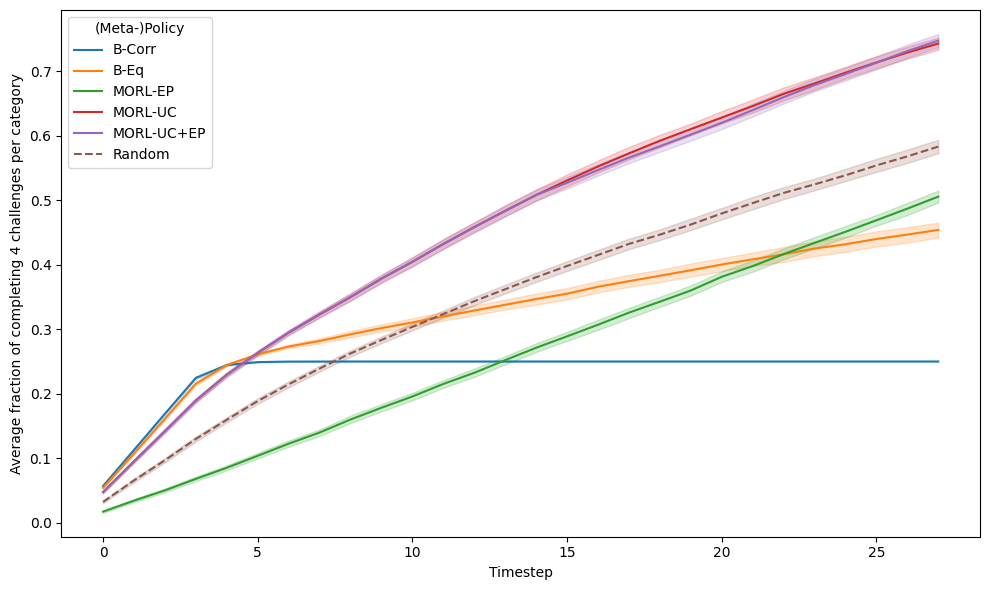

In [26]:
sim_utils.plot_fraction_completed(simulation_results, max_count_per_category=4, save_path=results_folder + "\\figures\\fraction_completed_per_category.svg")

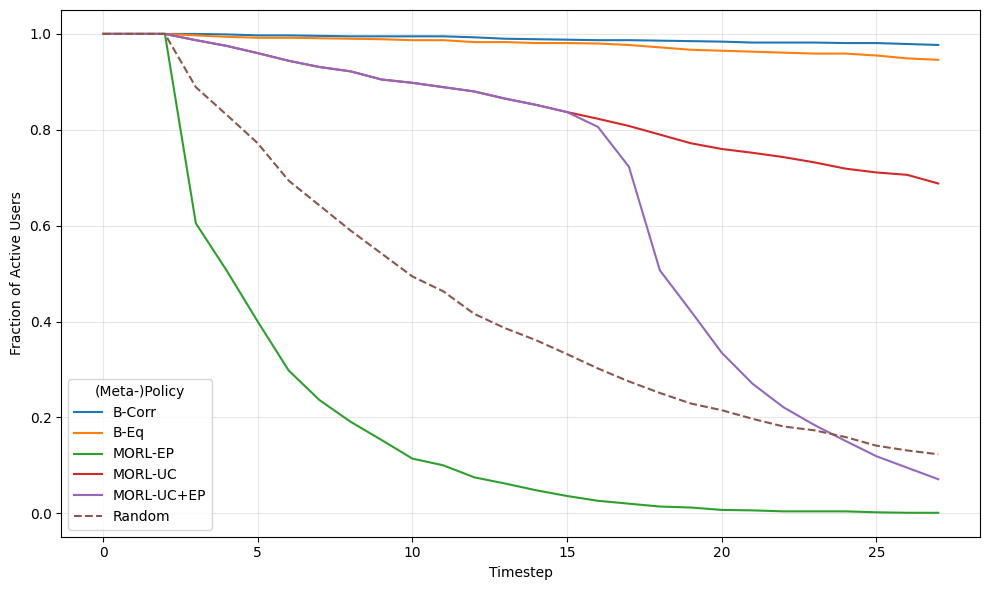

In [6]:
sim_utils.plot_dropout(simulation_results, threshold=3, save_path=results_folder + "\\figures\\dropout_over_time.svg")

In [27]:
reward_df = pd.DataFrame(
    simulation_results["rewards"].tolist(),
    columns=evaluation_names
)

reward_df["policy"] = simulation_results["policy"]
reward_df["user"] = simulation_results["user"]
reward_df["t"] = simulation_results["t"]
reward_df["completed"] = simulation_results["completed"]

completed_measures = ["Perceived Enjoyment", "Time Spent", "Difficulty", "Difficulty-weighted Adherence", "Perceived Usefulness"]
for measure in completed_measures:
    reward_df[measure] = reward_df.apply(lambda row: row[measure] if row['completed'] == 1 else 0, axis=1)

In [8]:
def format_cell(mean, imp, is_random):
    if is_random:
        return f"{mean:.2f}"
    arrow = "+" if imp > 0 else "-"
    return f"{mean:.2f} (${arrow}${abs(imp):.2f}\\%)"

def format_latex_to_clipboard(latex):
    latex = latex.replace("\\begin{table}", "\\begin{table}[ht]\\centering\\begin{threeparttable}")
    latex = latex.replace("\\end{table}", "\\begin{tablenotes}\\footnotesize\\item Policy abbreviations: MORL-EP = MORL with Expert Priority; MORL-UC = User Choice; MORL-UC+EP = Combination; B-Corr = Correlation-based baseline; B-Eq = Equal weights baseline; B-Rnd = Random baseline.\\end{tablenotes}\\end{threeparttable}\\end{table}")
    pyperclip.copy(latex)

In [28]:
user_driven_returns = ["Perceived Enjoyment", "Perceived Usefulness"]

completed_df = reward_df[reward_df["completed"] == 1]

policy_means, policy_stds = completed_df.groupby("policy")[user_driven_returns].mean(), completed_df.groupby("policy")[user_driven_returns].std()
improvement_from_random = policy_means.subtract(policy_means.loc["Random"], axis=1).div(policy_means.loc["Random"], axis=1) * 100

summary = policy_means.copy()
for col in user_driven_returns:
    summary[col] = summary.apply(lambda row: format_cell(row[col], improvement_from_random.loc[row.name, col], row.name == "Random"), axis=1)

display(summary)
latex = summary.to_latex(escape=False, 
                       caption="Mean of user-driven outcomes for each policy across simulations, alongside the improvement compared to the random baseline policy.", 
                       label="tab:reward_summary_user_driven")
format_latex_to_clipboard(latex)


,Perceived Enjoyment,Perceived Usefulness
policy,,
B-Corr,8.09 ($+$9.48\%),6.05 ($+$6.94\%)
B-Eq,8.06 ($+$9.04\%),5.99 ($+$5.87\%)
MORL-EP,7.45 ($+$0.81\%),5.55 ($-$1.83\%)
MORL-UC,7.95 ($+$7.63\%),6.02 ($+$6.34\%)
MORL-UC+EP,7.85 ($+$6.25\%),5.92 ($+$4.69\%)
Random,7.39,5.66


In [10]:
comparison_policies = ["MORL-UC", "MORL-EP", "MORL-UC+EP", "B-Eq", "B-Corr"]
for return_name in ["Return Willingness"]:
    user_means = reward_df.groupby(["policy", "user"])[return_name].mean().unstack(level=0)
    user_means_baseline = user_means["Random"]
    for policy in comparison_policies:
        comparison = user_means[policy]
        print(f"Comparison: {policy} vs Random for {return_name}")
        ba.two_sample_t_test(comparison, user_means_baseline)


Comparison: MORL-UC vs Random for Return Willingness
              mean     sd  hdi_2.5%  hdi_97.5%
improvement  0.158  0.016     0.127      0.189
effect_size  0.467  0.047     0.375      0.558
group1_mean  4.018  0.011     3.997      4.039
group2_mean  3.860  0.011     3.836      3.881
P(improvement > 0): 1.0000
P(Effect Size > 0.1): 1.0000
P(Effect Size > 0.2): 1.0000
P(Effect Size > 0.3): 1.0000
Comparison: MORL-EP vs Random for Return Willingness
              mean     sd  hdi_2.5%  hdi_97.5%
improvement  0.161  0.016     0.130      0.194
effect_size  0.451  0.047     0.362      0.545
group1_mean  4.021  0.012     3.998      4.043
group2_mean  3.860  0.011     3.838      3.882
P(improvement > 0): 1.0000
P(Effect Size > 0.1): 1.0000
P(Effect Size > 0.2): 1.0000
P(Effect Size > 0.3): 0.9995
Comparison: MORL-UC+EP vs Random for Return Willingness
              mean     sd  hdi_2.5%  hdi_97.5%
improvement  0.162  0.016     0.133      0.195
effect_size  0.471  0.047     0.384      0.565

In [32]:
T = 28
completion_per_user = (
    simulation_results
    .sort_values(["policy", "user", "t"])
    .groupby(["policy", "user"])
    .tail(1)
)[["policy", "user", "num_completed"]]
completion_per_user["Adherence"] = completion_per_user["num_completed"].div(T)

adherence_per_policy = completion_per_user.groupby("policy")["Adherence"].mean()
adherence_improvement_from_random = adherence_per_policy.subtract(adherence_per_policy.loc["Random"]).div(adherence_per_policy.loc["Random"]) * 100

expert_driven_returns = ["Return Willingness", "Diversity"]
policy_means, policy_stds = reward_df.groupby("policy")[expert_driven_returns].mean(), reward_df.groupby("policy")[expert_driven_returns].std()
policy_means['Adherence'] = adherence_per_policy
improvement_from_random = policy_means.subtract(policy_means.loc["Random"], axis=1).div(policy_means.loc["Random"], axis=1) * 100

summary = policy_means.copy()
for col in expert_driven_returns + ['Adherence']:
    summary[col] = summary.apply(lambda row: format_cell(row[col], improvement_from_random.loc[row.name, col], row.name == "Random"), axis=1)
display(summary)

latex = summary.to_latex(escape=False, 
                       caption="Mean of expert-driven outcomes for each policy across simulations, alongside the improvement compared to the random baseline policy.", 
                       label="tab:reward_summary_expert_driven")
latex = latex.replace("\\begin{table}", "\\begin{table}[ht]\\centering\\begin{threeparttable}")
latex = latex.replace("\\end{table}", "\\begin{tablenotes}\\footnotesize\\item Policy abbreviations: MORL-EP = MORL with Expert Priority; MORL-UC = User Choice; MORL-RC+EP = Combination; B-Corr = Correlation-based baseline; B-Eq = Equal weights baseline; B-Rnd = Random baseline.\\end{tablenotes}\\end{threeparttable}\\end{table}")
pyperclip.copy(latex)


,Return Willingness,Diversity,Adherence
policy,,,
B-Corr,4.08 ($+$5.79\%),0.00 ($-$100.00\%),0.89 ($+$78.34\%)
B-Eq,4.06 ($+$5.31\%),0.19 ($-$51.90\%),0.86 ($+$73.04\%)
MORL-EP,4.02 ($+$4.17\%),0.68 ($+$76.50\%),0.29 ($-$42.02\%)
MORL-UC,4.02 ($+$4.10\%),0.51 ($+$31.38\%),0.74 ($+$48.64\%)
MORL-UC+EP,4.02 ($+$4.18\%),0.54 ($+$40.19\%),0.54 ($+$8.30\%)
Random,3.86,0.39,0.50


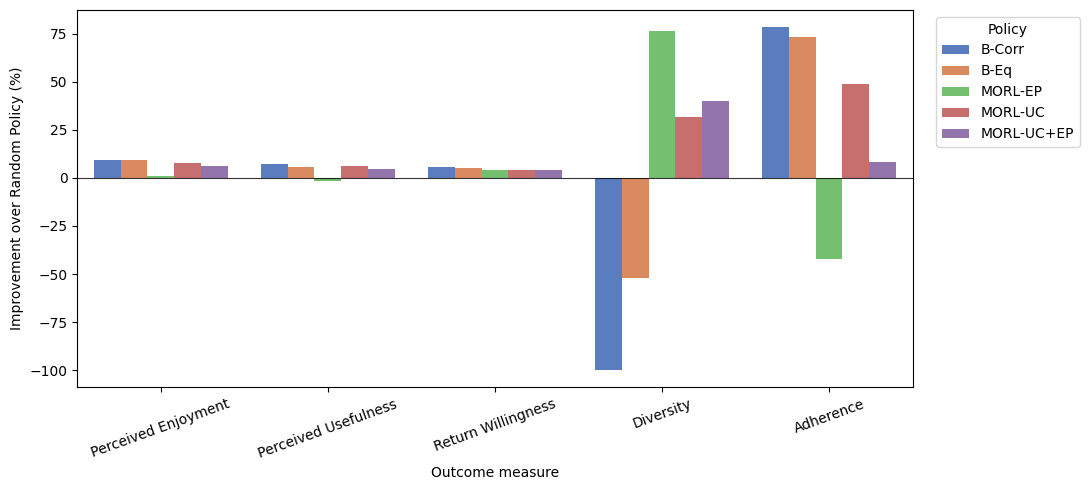

In [29]:
evaluation_names = ["Perceived Enjoyment", "Perceived Usefulness", "Return Willingness", "Diversity"]

policy_means = reward_df.groupby("policy")[evaluation_names].mean()
policy_means["Adherence"] = adherence_per_policy

completed = reward_df["completed"] == 1
completed_measures = ["Perceived Enjoyment", "Perceived Usefulness"]
for col in completed_measures:
    policy_means[col] = reward_df[completed].groupby("policy")[col].mean()

baseline = policy_means.loc["Random"]

improvement = (
    policy_means.drop(index="Random")
    .subtract(baseline)
    .divide(baseline)
    * 100
)

plot_df = (
    improvement
    .reset_index()
    .melt(id_vars="policy", var_name="objective", value_name="improvement")
)

plt.figure(figsize=(11, 5))

sns.barplot(
    data=plot_df,
    x="objective",
    y="improvement",
    hue="policy",
    palette="muted"
)

plt.ylabel("Improvement over Random Policy (%)")
plt.xlabel("Outcome measure")
plt.axhline(0, linewidth=0.8, color="black", alpha=0.8)

plt.xticks(rotation=20)
plt.legend(title="Policy", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.savefig(results_folder + "figures\\improvement_over_random.svg", bbox_inches="tight")
plt.tight_layout()
plt.show()

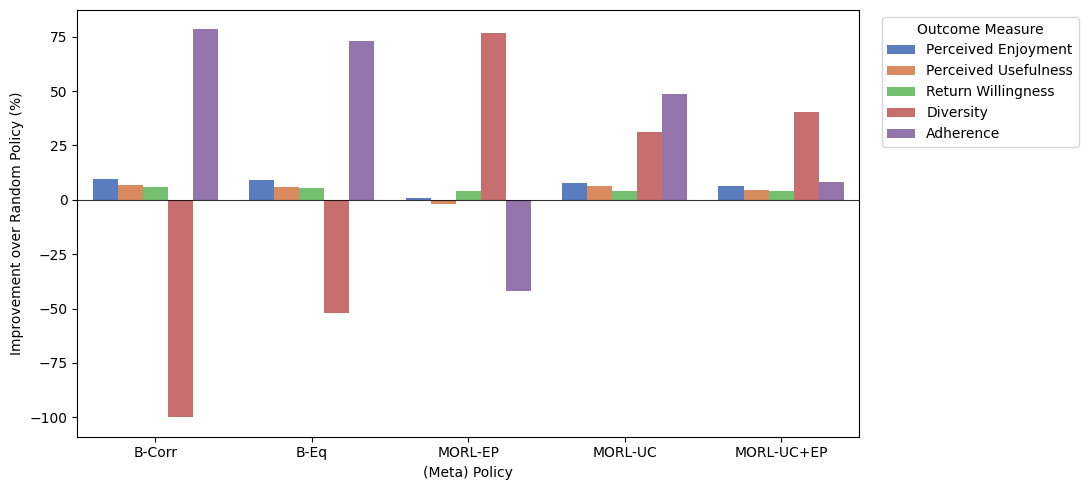

In [30]:
plt.figure(figsize=(11, 5))

sns.barplot(
    data=plot_df,
    x="policy",
    y="improvement",
    hue="objective",
    palette="muted"
)

plt.ylabel("Improvement over Random Policy (%)")
plt.xlabel("(Meta) Policy")
plt.axhline(0, linewidth=0.8, color="black", alpha=0.8)
plt.legend(title="Outcome Measure", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.savefig(results_folder + "figures\\improvement_over_random.svg", bbox_inches="tight")
plt.tight_layout()
plt.show()

In [14]:
# analyze per time state, the time spent on the activity
reward_df["Time State"] = simulation_results["state"].apply(lambda x: x[1])
reward_df["challenge_id"] = simulation_results["challenge_id"]
reward_df["challenge_time"] = action_data.loc[reward_df["challenge_id"], "time_spent"].values

mean_time_spent_per_user = reward_df.groupby(["policy", "user", "Time State"])["challenge_time"].mean().reset_index()
mean_time_spent_per_policy_time = mean_time_spent_per_user.groupby(["policy", "Time State"])["challenge_time"].mean().unstack()
mean_time_spent_per_policy_time["ratio"] = (
    mean_time_spent_per_policy_time[1] / mean_time_spent_per_policy_time[0]
)
baseline_ratio = mean_time_spent_per_policy_time.loc["Random", "ratio"]
mean_time_spent_per_policy_time['improvement'] = mean_time_spent_per_policy_time["ratio"].subtract(baseline_ratio).div(baseline_ratio) * 100

summary = mean_time_spent_per_policy_time.copy()
summary['Low'] = summary[0].round(2).astype(str)
summary['High'] = summary[1].round(2).astype(str)
summary['Ratio'] = summary.apply(lambda row: format_cell(row['ratio'], row['improvement'], row.name == "Random"), axis=1)
summary = summary[['Low', 'High', 'Ratio']]
display(summary)
latex =summary.to_latex(escape=False,
                       caption="Mean time spent ratings of the suggested challenges for low vs high time available states for each policy across simulations, alongside the ratio between them and the improvement compared to the random baseline policy. A higher ratio is better.", 
                       label="tab:time_spent_summary")
format_latex_to_clipboard(latex)

Time State,Low,High,Ratio
policy,,,
B-Corr,10.67,12.27,1.15 ($+$15.00\%)
B-Eq,10.18,11.58,1.14 ($+$13.80\%)
MORL-EP,9.43,10.37,1.10 ($+$9.95\%)
MORL-UC,10.26,11.61,1.13 ($+$13.10\%)
MORL-UC+EP,9.59,11.13,1.16 ($+$16.08\%)
Random,10.02,10.02,1.00


In [15]:
# analyze per time state, the time spent on the activity
reward_df["TIR"] = simulation_results["state"].apply(lambda x: x[0])
reward_df["challenge_difficulty"] = action_data.loc[reward_df["challenge_id"], "time_spent"].values

mean_time_spent_per_user = reward_df.groupby(["policy", "user", "TIR"])["challenge_difficulty"].mean().reset_index()
mean_time_spent_per_policy_time = mean_time_spent_per_user.groupby(["policy", "TIR"])["challenge_difficulty"].mean().unstack()
mean_time_spent_per_policy_time["ratio"] = (
    mean_time_spent_per_policy_time[1] / mean_time_spent_per_policy_time[0]
)
baseline_ratio = mean_time_spent_per_policy_time.loc["Random", "ratio"]
mean_time_spent_per_policy_time['improvement'] = mean_time_spent_per_policy_time["ratio"].subtract(baseline_ratio).div(baseline_ratio) * 100

summary = mean_time_spent_per_policy_time.copy()
summary['Low'] = summary[0].round(2).astype(str)
summary['High'] = summary[1].round(2).astype(str)
summary['Ratio'] = summary.apply(lambda row: format_cell(row['ratio'], row['improvement'], row.name == "Random"), axis=1)
summary = summary[['Low', 'High', 'Ratio']]
display(summary)
latex =summary.to_latex(escape=False,
                       caption="Mean difficulty ratings of the suggested challenges for low vs high time available states for each policy across simulations, alongside the ratio between them and the improvement compared to the random baseline policy. A higher ratio is better.", 
                       label="tab:difficulty_summary")
format_latex_to_clipboard(latex)

TIR,Low,High,Ratio
policy,,,
B-Corr,10.77,11.89,1.10 ($+$10.33\%)
B-Eq,11.04,9.97,0.90 ($-$9.67\%)
MORL-EP,9.49,10.09,1.06 ($+$6.39\%)
MORL-UC,11.05,10.39,0.94 ($-$5.94\%)
MORL-UC+EP,10.12,10.06,0.99 ($-$0.55\%)
Random,10.02,10.02,1.00


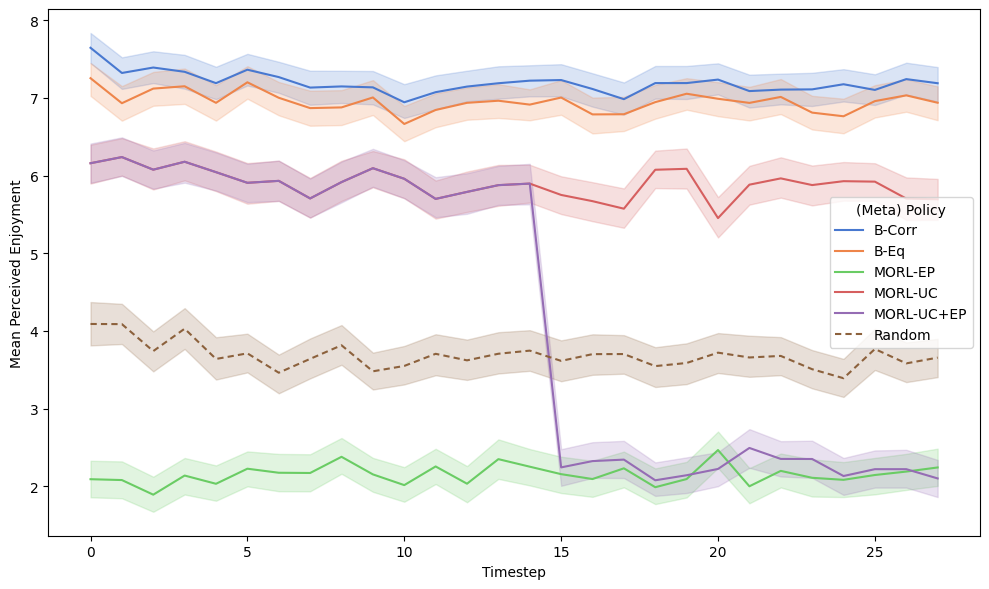

In [ ]:
plotting_measures = ["Perceived Enjoyment", "Perceived Usefulness", "Return Willingness", "Diversity"]
policy_order = sorted(reward_df["policy"].unique())
for measure in plotting_measures[:1]:
    sim_utils.plot_seaborn(reward_df, measure, save_path=results_folder + f"figures\\outcomes\\{measure}.svg")

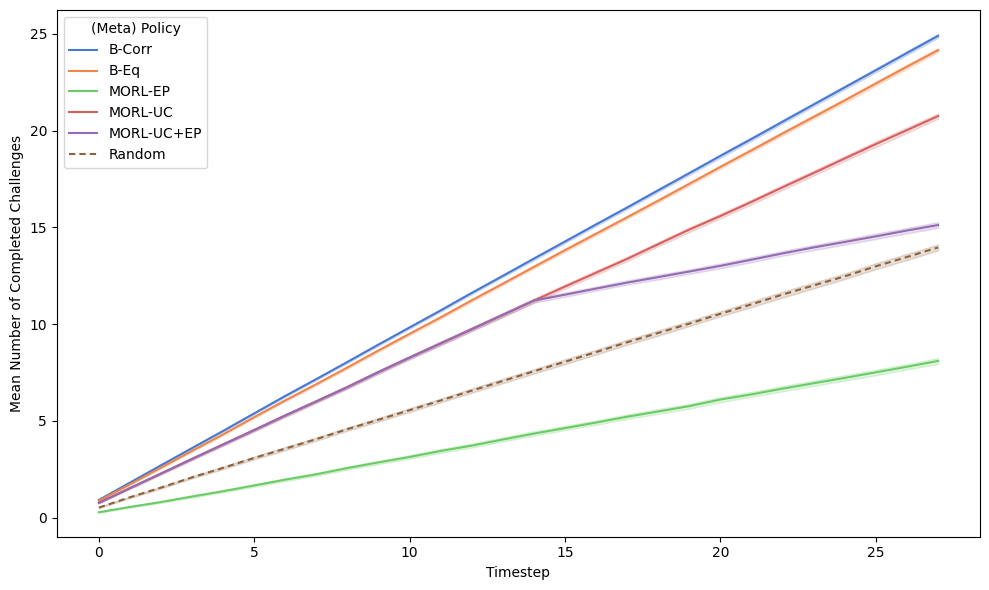

In [ ]:
reward_df["Number of Completed Challenges"] = simulation_results["num_completed"]
sim_utils.plot_seaborn(reward_df, "Number of Completed Challenges", save_path=results_folder + "figures\\outcomes\\num_completed.svg")

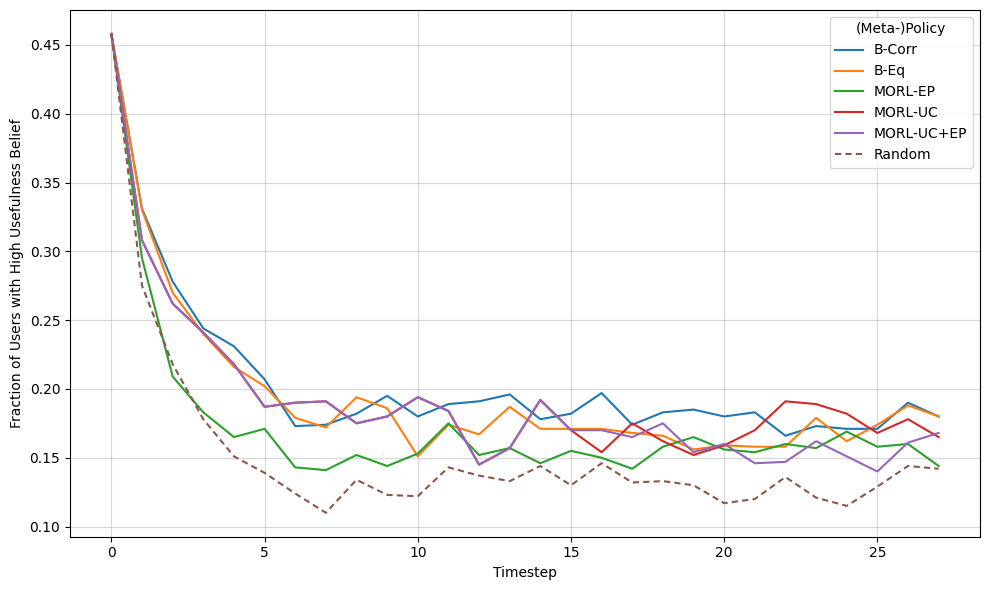

In [17]:
sim_utils.plot_state_trajectory(simulation_results)